In [27]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [29]:
data = pd.read_csv('cleanedAweExperienceSurveyResponses.csv')
print(data.head)

cleaned_data = data.copy()

<bound method NDFrame.head of               timestamp age_range                         env_growth  \
0     4/9/2026 11:42:15     19-21                           Suburban   
1     4/9/2026 11:42:37     19-21                           Suburban   
2     4/9/2026 11:44:34     19-21                       Rural/Remote   
3     4/9/2026 11:46:07     19-21                           Suburban   
4     4/9/2026 11:46:22     19-21                       Highly urban   
5     4/9/2026 11:46:43     19-21                           Suburban   
6     4/9/2026 11:49:39     19-21                       Rural/Remote   
7     4/9/2026 12:10:59     19-21                           Suburban   
8     4/9/2026 12:18:42     25-30                           Suburban   
9     4/9/2026 12:19:05     19-21                           Suburban   
10    4/9/2026 12:27:44     19-21                           Suburban   
11    4/9/2026 12:28:08     17-18                           Suburban   
12    4/9/2026 12:28:51     25-30 

In [37]:
# Select your phenotype features
phenotype_features = [
    'age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
    'awe_scale_1',
'awe_scale_2',
'awe_scale_3',
'awe_scale_4',
'awe_scale_5',
'awe_scale_6',
'awe_scale_7',
'awe_scale_8',
'awe_scale_9',
'awe_scale_10',
'awe_scale_11',
'awe_scale_12'
]

# One-hot encode the text categories
X_encoded = pd.get_dummies(cleaned_data[phenotype_features], drop_first=True)

In [39]:
# 2. Impute (looks at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

# 3. Scale
X_scaled = scaler.fit_transform(X_imputed)

# There a NaN values in some of the columns (example regular_practices has 34 NaNs).
# However, dropping all rows with NaN dimishes the value in an alredy small dataset.
# Using KNN Imputer:
# looks at other "similar" respondents. If a respondent looks like Cluster A in every 
#     other category but is missing their awe_scale_5 score, it will fill that gap based 
#     on the scores of people similar to them.

In [43]:
# Scale the data (Essential for K-Means to treat 1-5 scales and 0/1 dummies fairly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Build the Cluster Model
# We'll stick with 3 clusters to look for distinct "Phenotypes"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cleaned_data['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
cleaned_data['pca_1'] = pca_data[:, 0]
cleaned_data['pca_2'] = pca_data[:, 1]

# 5. ANALYSIS: Identify the "Awe Phenotypes"
# We look at the average scores for each cluster to define them
phenotype_profiles = cleaned_data.groupby('cluster')[phenotype_features].agg(lambda x: x.mode()[0])
print("--- Phenotype Profiles (Dominant Traits) ---")
print(phenotype_profiles)

--- Phenotype Profiles (Dominant Traits) ---
        age_range env_growth                    worldview activity_primary  \
cluster                                                                      
0           25-30   Suburban  Spiritual but not Religious             Work   
1           19-21   Suburban           Religious/Theistic         Studying   
2           22-24   Suburban           Atheist/Naturalist             Work   

        gender_assigned                edu_level income_bracket  \
cluster                                                           
0                Female            Undergraduate          0-50K   
1                Female  High school Diploma/GED          0-50K   
2                Female            Undergraduate          0-50K   

             socioec_status  awe_scale_1  awe_scale_2  awe_scale_3  \
cluster                                                              
0          Low middle class            4            4            5   
1        Upper mid


--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---
chills_ability        0.0        1.0
cluster                             
0               60.714286  39.285714
1               70.833333  29.166667
2               73.913043  26.086957


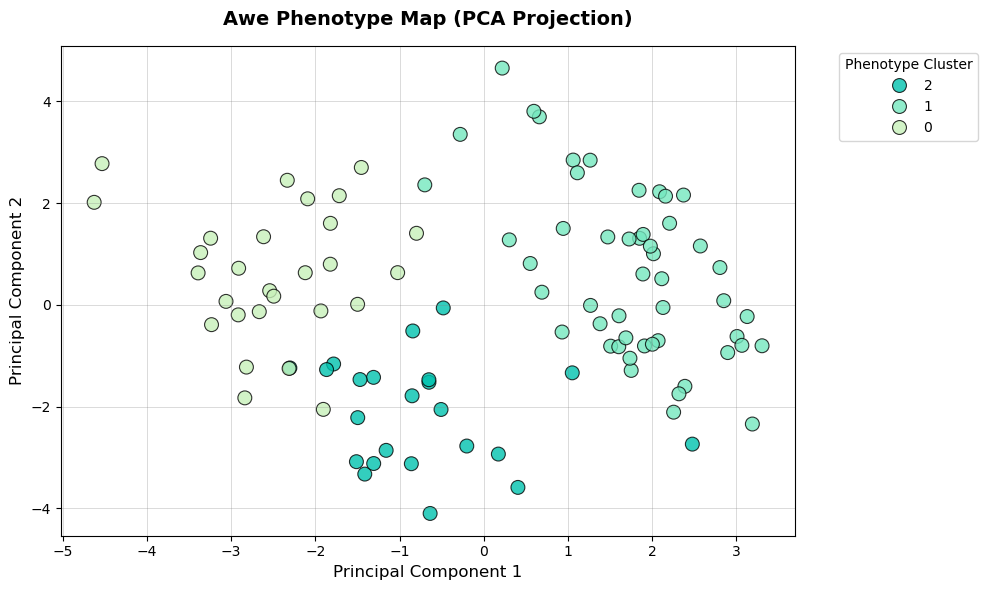

In [63]:
# 6. TARGET LINK: How does each phenotype relate to the SPARK trait?
# Assuming 'chills_ability' is coded as 0/1 or Yes/No
spark_link = cleaned_data.groupby('cluster')['chills_ability'].value_counts(normalize=True).unstack() * 100
print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
print(spark_link)

# 7. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_data, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [47]:
copy_df = cleaned_data.copy()
# print(copy_df.head)
# Pass the entire dataframe, but tell it which columns to encode
# This keeps all other columns exactly as they are.
encodedCopyDf = pd.get_dummies(copy_df, columns=phenotype_features, drop_first=True)

# Now df_encoded contains your original scale scores + the new dummy variables
# print(encodedCopyDf)

In [49]:
# 1. Convert the cluster column to string directly in cleaned_data
# This ensures Plotly treats them as discrete categories (colors) rather than a continuous scale
cleaned_data['cluster'] = cleaned_data['cluster'].astype(str)
cleaned_data['Participant_ID'] = cleaned_data.index + 1

# 2. Map your scores for the ternary axes
cleaned_data['Religious_Score'] = cleaned_data['trigger_spiritual_1'] + cleaned_data['trigger_spiritual_2']
cleaned_data['Naturalist_Score'] = cleaned_data['trigger_spiritual_4']
cleaned_data['Spiritual_Score'] = cleaned_data['trigger_spiritual_3']

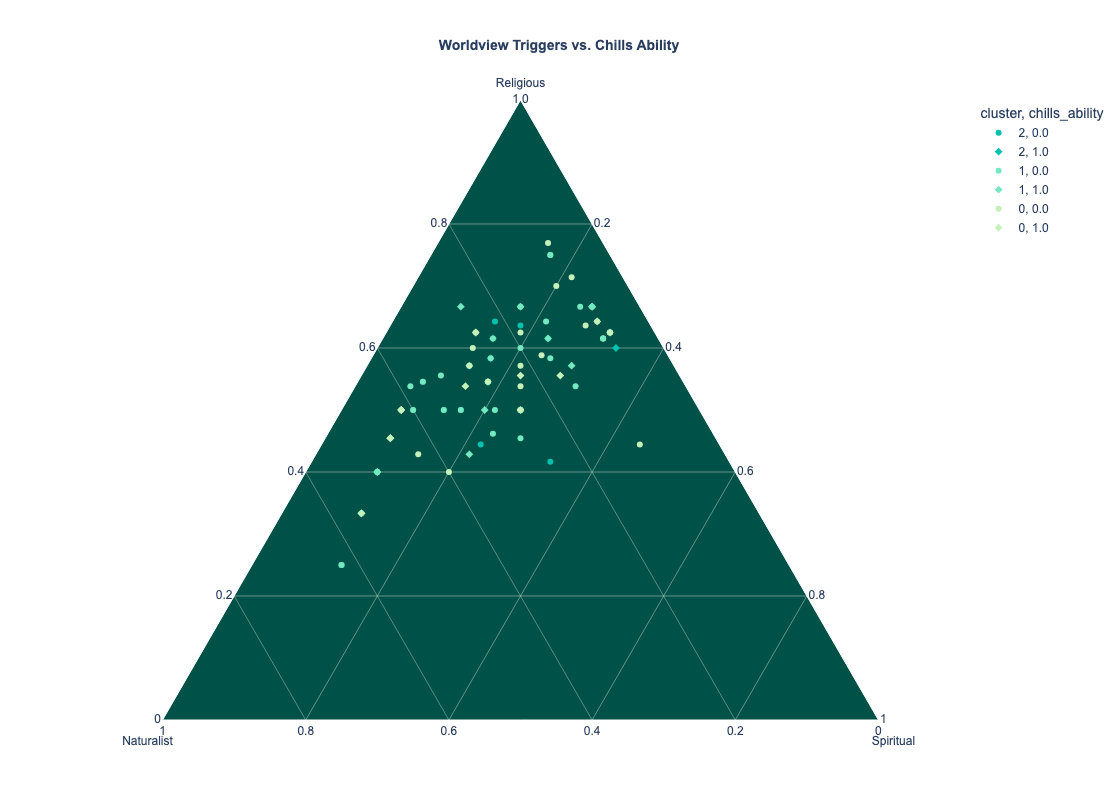

In [87]:
# 3. Build the plot using cleaned_data
fig = px.scatter_ternary(
    cleaned_data, 
    a="Religious_Score", 
    b="Naturalist_Score", 
    c="Spiritual_Score",
    color="cluster",           
    symbol="chills_ability",   
    size_max=15,
    # Plotly titles use HTML tags for bolding
    title="<b>Worldview Triggers vs. Chills Ability</b>",
    labels={
        "Religious_Score": "Theistic Triggers", 
        "Naturalist_Score": "Naturalist Triggers", 
        "Spiritual_Score": "Spiritual Triggers"
    },
    color_discrete_sequence=pheno_colors, # Applying your hex colors
    hover_data=['Participant_ID', 'worldview']
)

# Update layout for larger display and specific styling
fig.update_layout({
    'width': 1000,
    'height': 800,
    'title': {
        'font': {'size': 14}, # Requested title size
        'x': 0.5,             # Center the title
        'xanchor': 'center'
    },
    'ternary': {
        'sum': None,
        'aaxis': {
            'title': 'Religious', 
            'titlefont': {'size': 12}, # Requested axis label size
            'gridcolor': '#E3E3E3',       # Grid color
            'gridwidth': 0.4           # Grid weight
        },
        'baxis': {
            'title': 'Naturalist', 
            'titlefont': {'size': 12}, 
            'gridcolor': '#E3E3E3', 
            'gridwidth': 0.4
        },
        'caxis': {
            'title': 'Spiritual', 
            'titlefont': {'size': 12}, 
            'gridcolor': '#E3E3E3', 
            'gridwidth': 0.4
        },
        'bgcolor': '#005248' # Keeps the background clean for the grey grid
    },
    'legend': {'font': {'size': 12}},
    'font': {'family': "Arial"} # Clean font for all text
})

fig.show()

In [ ]:
# # Loop through each cluster and each chills_ability status
# for cluster_id in cleaned_data['cluster'].unique():
#     for ability in cleaned_data['chills_ability'].unique():
        
#         # 3. Create the subset
#         subset = cleaned_data[
#             (cleaned_data['cluster'] == cluster_id) & 
#             (cleaned_data['chills_ability'] == ability)
#         ]
        
#         # 4. Generate a clean filename
#         # Replaces spaces or special characters to avoid file errors
#         safe_ability = str(ability).replace(" ", "_").lower()
#         filename = f"cluster_{cluster_id}_chills_{safe_ability}.csv"
        
#         # 5. Save the CSV
#         if not subset.empty:
#             subset.to_csv(filename, index=False)
#             print(f"Saved: {filename} ({len(subset)} participants)")

# Gets row data for each identified cluster and exports as csv